# the basics of `pandeia`

First, before doing anything else you need to install `pandeia` and all related reference files.  Follow the installation instructions [linked on the Pandeia documentation](https://outerspace.stsci.edu/spaces/PEN/pages/77530136/Pandeia+Engine+Installation).  For the `synphot` altas reference files, you only _really_ need the first one linked (called "synphot1_....tar") to get `pandeia` up and running.

Once you have installed, downloaded, and added `export` paths, you can continue.

In [1]:
# importing pandeia things
from pandeia.engine.perform_calculation import perform_calculation
from pandeia.engine.calc_utils import build_default_calc
import pandeia.engine


# importing other things
# -----------------------
import os # for setting environment variables, if needed
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# # if you haven't set your environment variables elsewhere, uncomment this and do it here:
# os.environ["pandeia_refdata"] = "/path/to/pandeia/pandeia_data-2026.7-jwst/"
# os.environ["PSF_DIR"] = "/path/to/pandeia/pandeia_psfs-2026.7rc1-jwst/"
# os.environ["PYSYN_CDBS"] = "/path/to/synphot/grp/redcat/trds/"


In [2]:
# testing the pandeia installation and where your reference files are located
pandeia.engine.pandeia_version()

Pandeia Engine version:  2026.7
Pandeia RefData version: 2026.7
Pandeia PSFs version:    2026.7
Synphot Data:            /Users/taylorhutchison/programs/synphot/grp/redcat/trds/


## 1. Starting a new ETC simulation

We're going to setup a basic ETC calculation.  STScI does most things in dictionaries -- and this applies to `pandeia` as well.  So the _input_ ETC setup will be using a nested dictionary to define all the components, and the _output_ from the ETC will also be in dictionary format.  If you're not super familiar with dictionaries, check out python's docs [(here)](https://docs.python.org/3/tutorial/datastructures.html#dictionaries).  STScI includes descriptions of the nested structure used in `pandeia` in the jdox [(linked here)](https://jwst-docs.stsci.edu/jwst-exposure-time-calculator-overview/jwst-etc-pandeia-engine-tutorial/pandeia-configuration-dictionaries#gsc.tab=0).

First, it may be helpful to see what that function entails:

In [3]:
build_default_calc?

Signature: build_default_calc(telescope, instrument, mode, **kwargs)
Docstring:
Build a default calculation given an telescope, instrument, and mode

Parameters
----------
telescope: string
    Telescope identifier string. Currently supports jwst, roman, and hst.
instrument: string
    Instrument identifier string.
mode: string
    Mode identifier string.

Returns
-------
calc: dict
    Engine output API compliant dict defining a calculation
File:      /opt/miniconda3/envs/stenv/lib/python3.13/site-packages/pandeia/engine/calc_utils.py
Type:      function

.  
.  
For the calculation, let's use NIRSpec and the MSA mode:

In [4]:
setup = build_default_calc('jwst','nirspec','mos')

#-- uncomment the below if you want to see what the base NIRSpec/MSA template dictionary looks like
# setup

To navigate the nested dictionary, you can use the `.key()` command to see the entries at each level.  If we do this for the top level of the `setup` variable, we see a list of specifications that look very similar to what you would define in the online ETC version.

In [5]:
# looking at the top-level keys for the setup dict
setup.keys()

dict_keys(['configuration', 'scene', 'background', 'background_level', 'calculation', 'strategy'])

### Updating the ETC parameters

Here's the ETC sim we want to do:

* NIRSpec/MSA
* NRSIRS2 readout mode
* prism/clear
* exposure setup: 16 groups/int, 1 int/exp, 3 exp (about an hr)
* medium background level
* located in Q3 center on detector (default location)


The source we'll be "making":

* 24 abmag in F444W
* point source, centered in slit (default)
* sed: simple stellar pop model, log(age)=6, z/H=-2.50
* redshift 5


In [6]:
# updating background level first
setup['background_level'] = 'medium'

# now the instrument and detector specs (which nest inside configuration)
setup['configuration']['instrument']['disperser'] = 'prism'
setup['configuration']['instrument']['filter'] = 'clear'
setup['configuration']['detector']['ngroup'] = 16
setup['configuration']['detector']['nint'] = 1
setup['configuration']['detector']['nexp'] = 3 # 3 dithers for 1 pointing

# now making our source, all nested inside scene, list index 0 for the first source
# --- normalization
setup['scene'][0]['spectrum']['normalization']['type'] = 'jwst' # using JWST bandpass
setup['scene'][0]['spectrum']['normalization']['norm_fluxunit'] = 'abmag'
setup['scene'][0]['spectrum']['normalization']['norm_flux'] = 24 # abmag units
setup['scene'][0]['spectrum']['normalization']['bandpass'] = 'nircam,lw_imaging,f444w'
# --- source redshift
setup['scene'][0]['spectrum']['redshift'] = 5.0
# --- sed
setup['scene'][0]['spectrum']['sed']['key'] = 'ssp_a6.00_zm2.50'
setup['scene'][0]['spectrum']['sed']['sed_type'] = 'stellar_pop'


# finally, updating strategy
setup['strategy']['reference_wavelength'] = 3.0 # randomly chosen; if lines present, update to one of them

### Running the ETC and checking outputs!

In [7]:
result = perform_calculation(setup)

In [8]:
# looking at the top-level keys for the output dict
result.keys()

dict_keys(['sub_reports', 'input', '1d', '2d', '3d', 'scalar', 'information', 'transform', 'warnings', 'web_report'])

In [9]:
result['information'].keys()

dict_keys(['calc_type', 'exposure_specification'])

In [10]:
result['1d'].keys()

dict_keys(['wave_pix', 'wave_calc', 'target', 'fp', 'bg', 'bg_rate', 'sn', 'extracted_noise', 'extracted_flux', 'extracted_flux_plus_bg', 'total_flux', 'extracted_bg_total', 'extracted_bg_only', 'extracted_contamination', 'n_partial_saturated', 'n_full_saturated'])

In [11]:
# pulling out the total time from the information dict
total_seconds = result['information']['exposure_specification']['total_exposure_time']
total_hr = total_seconds / 3600
print(f'Total science time: {round(total_hr,2)} hr')

Total science time: 0.58 hr


### Saving the output

Before we go further, let's save the output.  There's a few ways you can do this.

1. Extract the information you want from `result` and save as FITS or txt files, etc.
2. Save the entire dictionary as a [pickle (.pkl)](https://docs.python.org/3/library/pickle) file
3. Save the entire dictionary as a .json file (human-readable, unlike pickle)

I primarily use #1, but below we'll use #2 and #3 for the `setup` and `result` dictionaries, respectively, to show how to do it.

In [12]:
type(setup), type(result)

(dict, dict)

In [13]:
import json, pickle

# also we'll save the setup dictionary, too!
with open('setup.json','w') as s:
    json.dump(setup, s)

# saving the output dictionary
with open('result.pkl','wb') as r:
    pickle.dump(result, r)

### Looking at the output

You can explore the various outputs provided, but if all you need is the "extracted" 1D spectrum, you can go straight to that nested dictionary.  However, it's worth noting that most/all items in the `1d` nested dictionary are lists.  The flux, S/N, etc., items will generally have the first column be the wavelength array and the second column being the spectrum of choice.

In [14]:
type(result['1d']['sn']),len(result['1d']['sn'])

(list, 2)

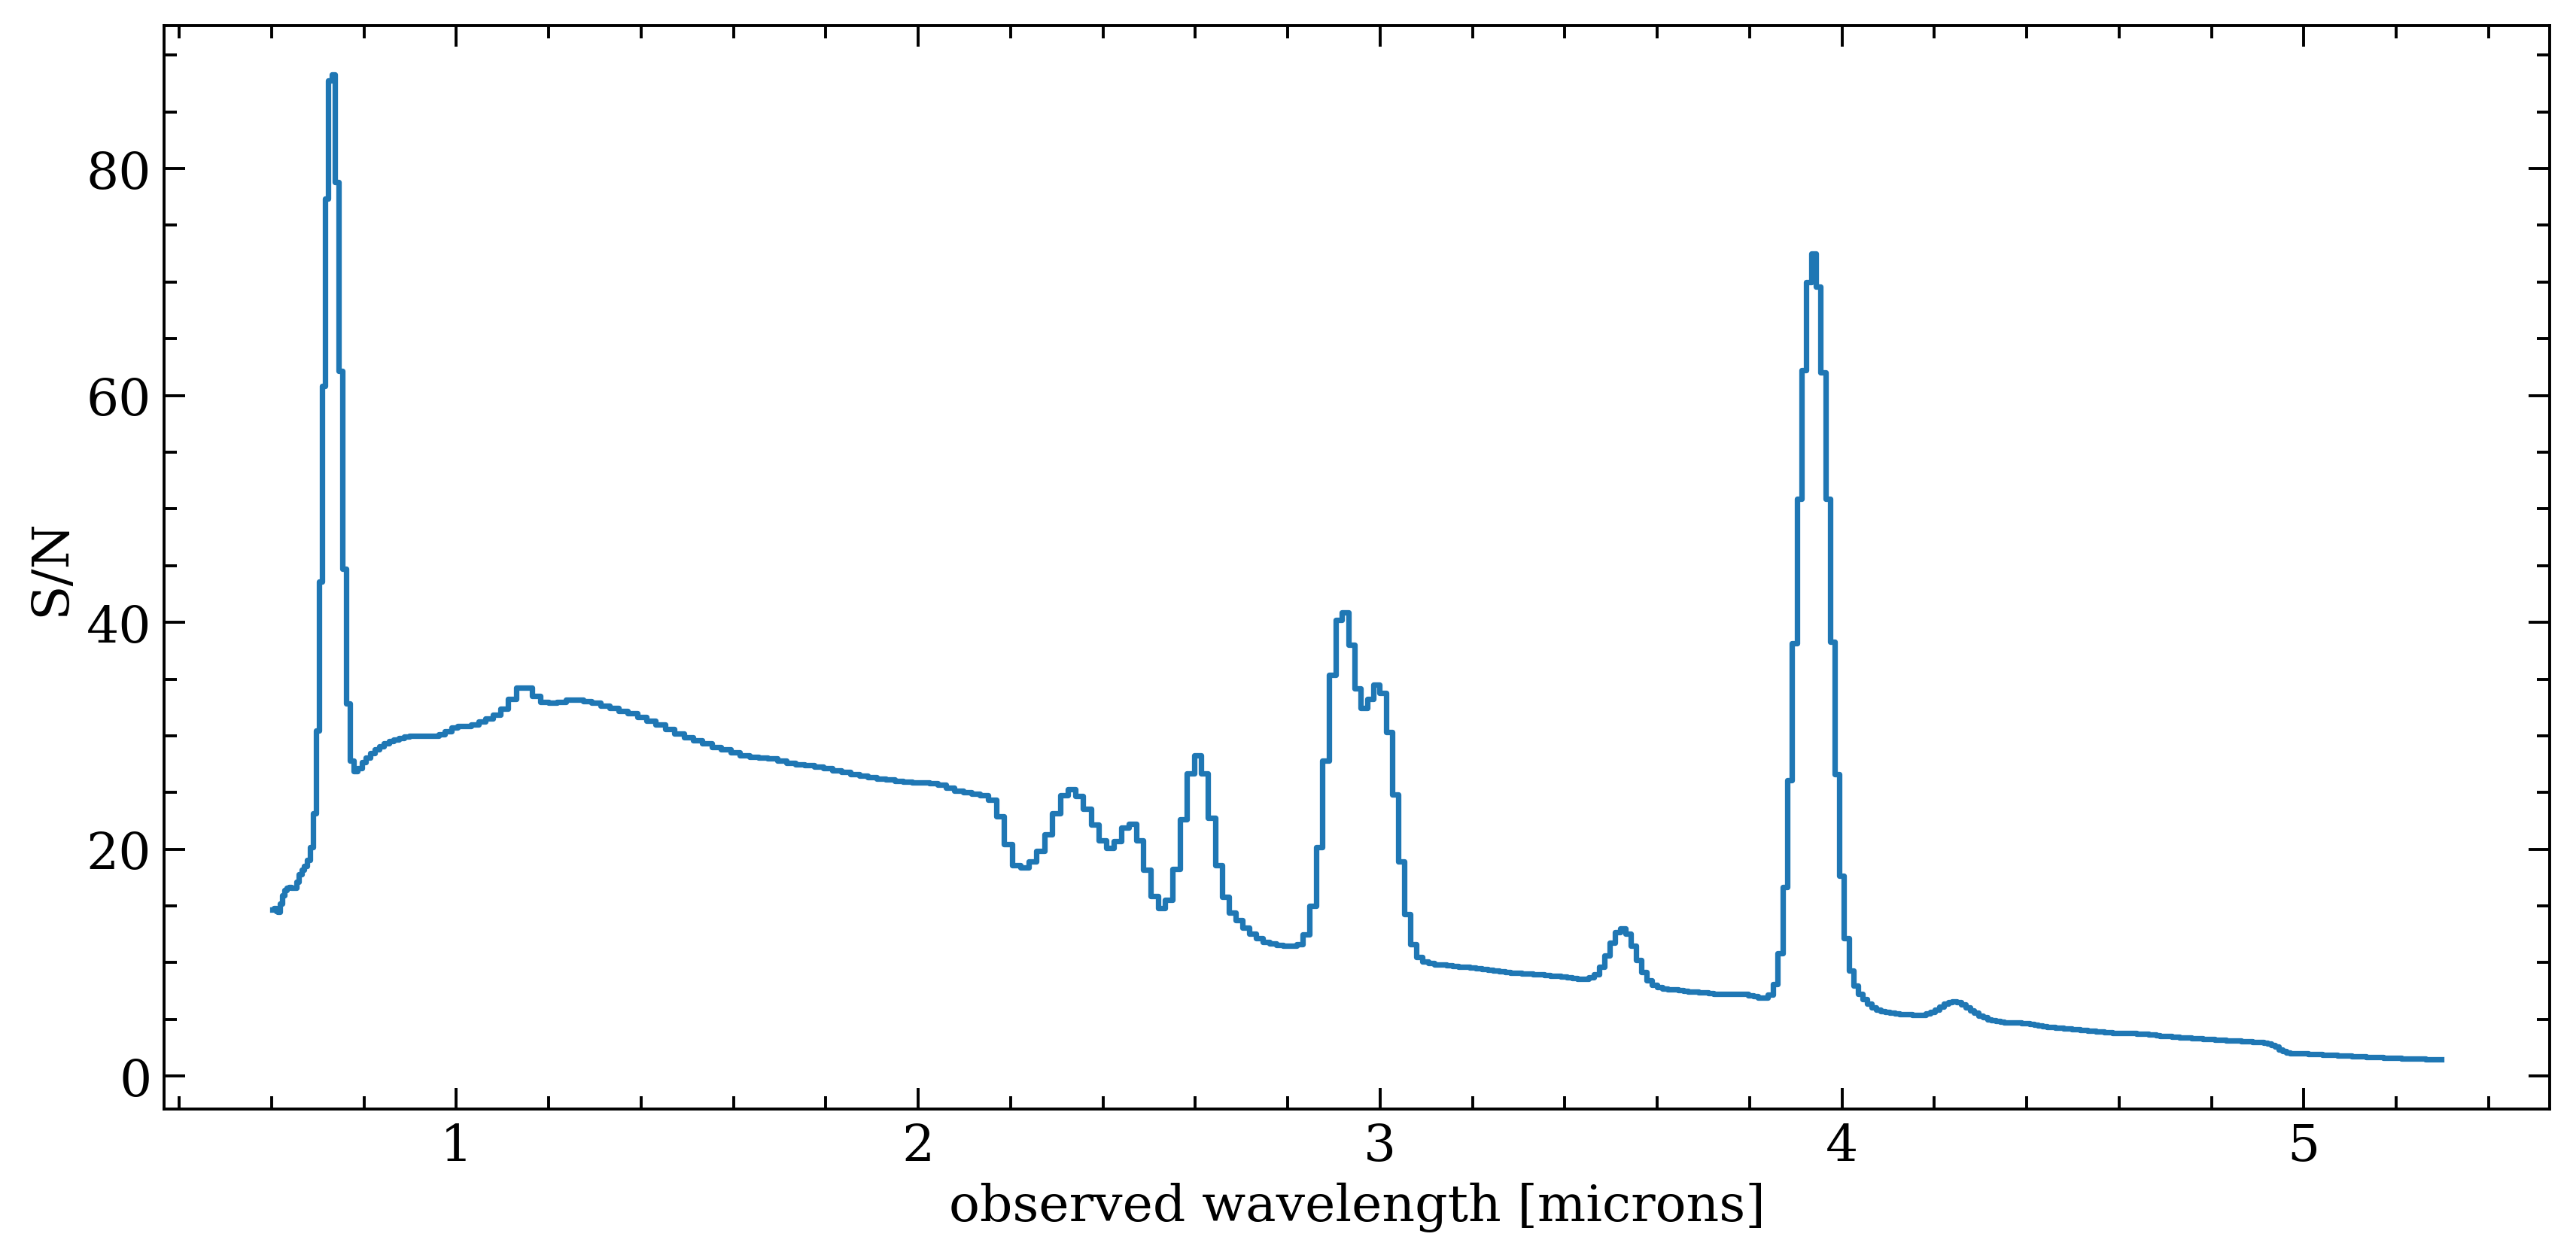

In [15]:
plt.figure(figsize=(10,5))

snr_1d = result['1d']['sn'][1] # the S/N spectrum
wave_1d = result['1d']['sn'][0] # the wavelength array

plt.step(wave_1d,snr_1d,where='mid')

plt.xlabel('observed wavelength [microns]')
plt.ylabel('S/N')

plt.tight_layout()
plt.show()
plt.close('all')

.  
.  
If you wanted to look at the 2D as well, perhaps as part of your proposal visualizations, you can access the `2d` nested dictionary:

In [16]:
result['2d'].keys()

dict_keys(['detector_unrotated', 'snr_unrotated', 'saturation_unrotated', 'ngroups_map_unrotated', 'detector', 'snr', 'saturation', 'ngroups_map'])

In [17]:
type(result['2d']['snr'])

numpy.ndarray

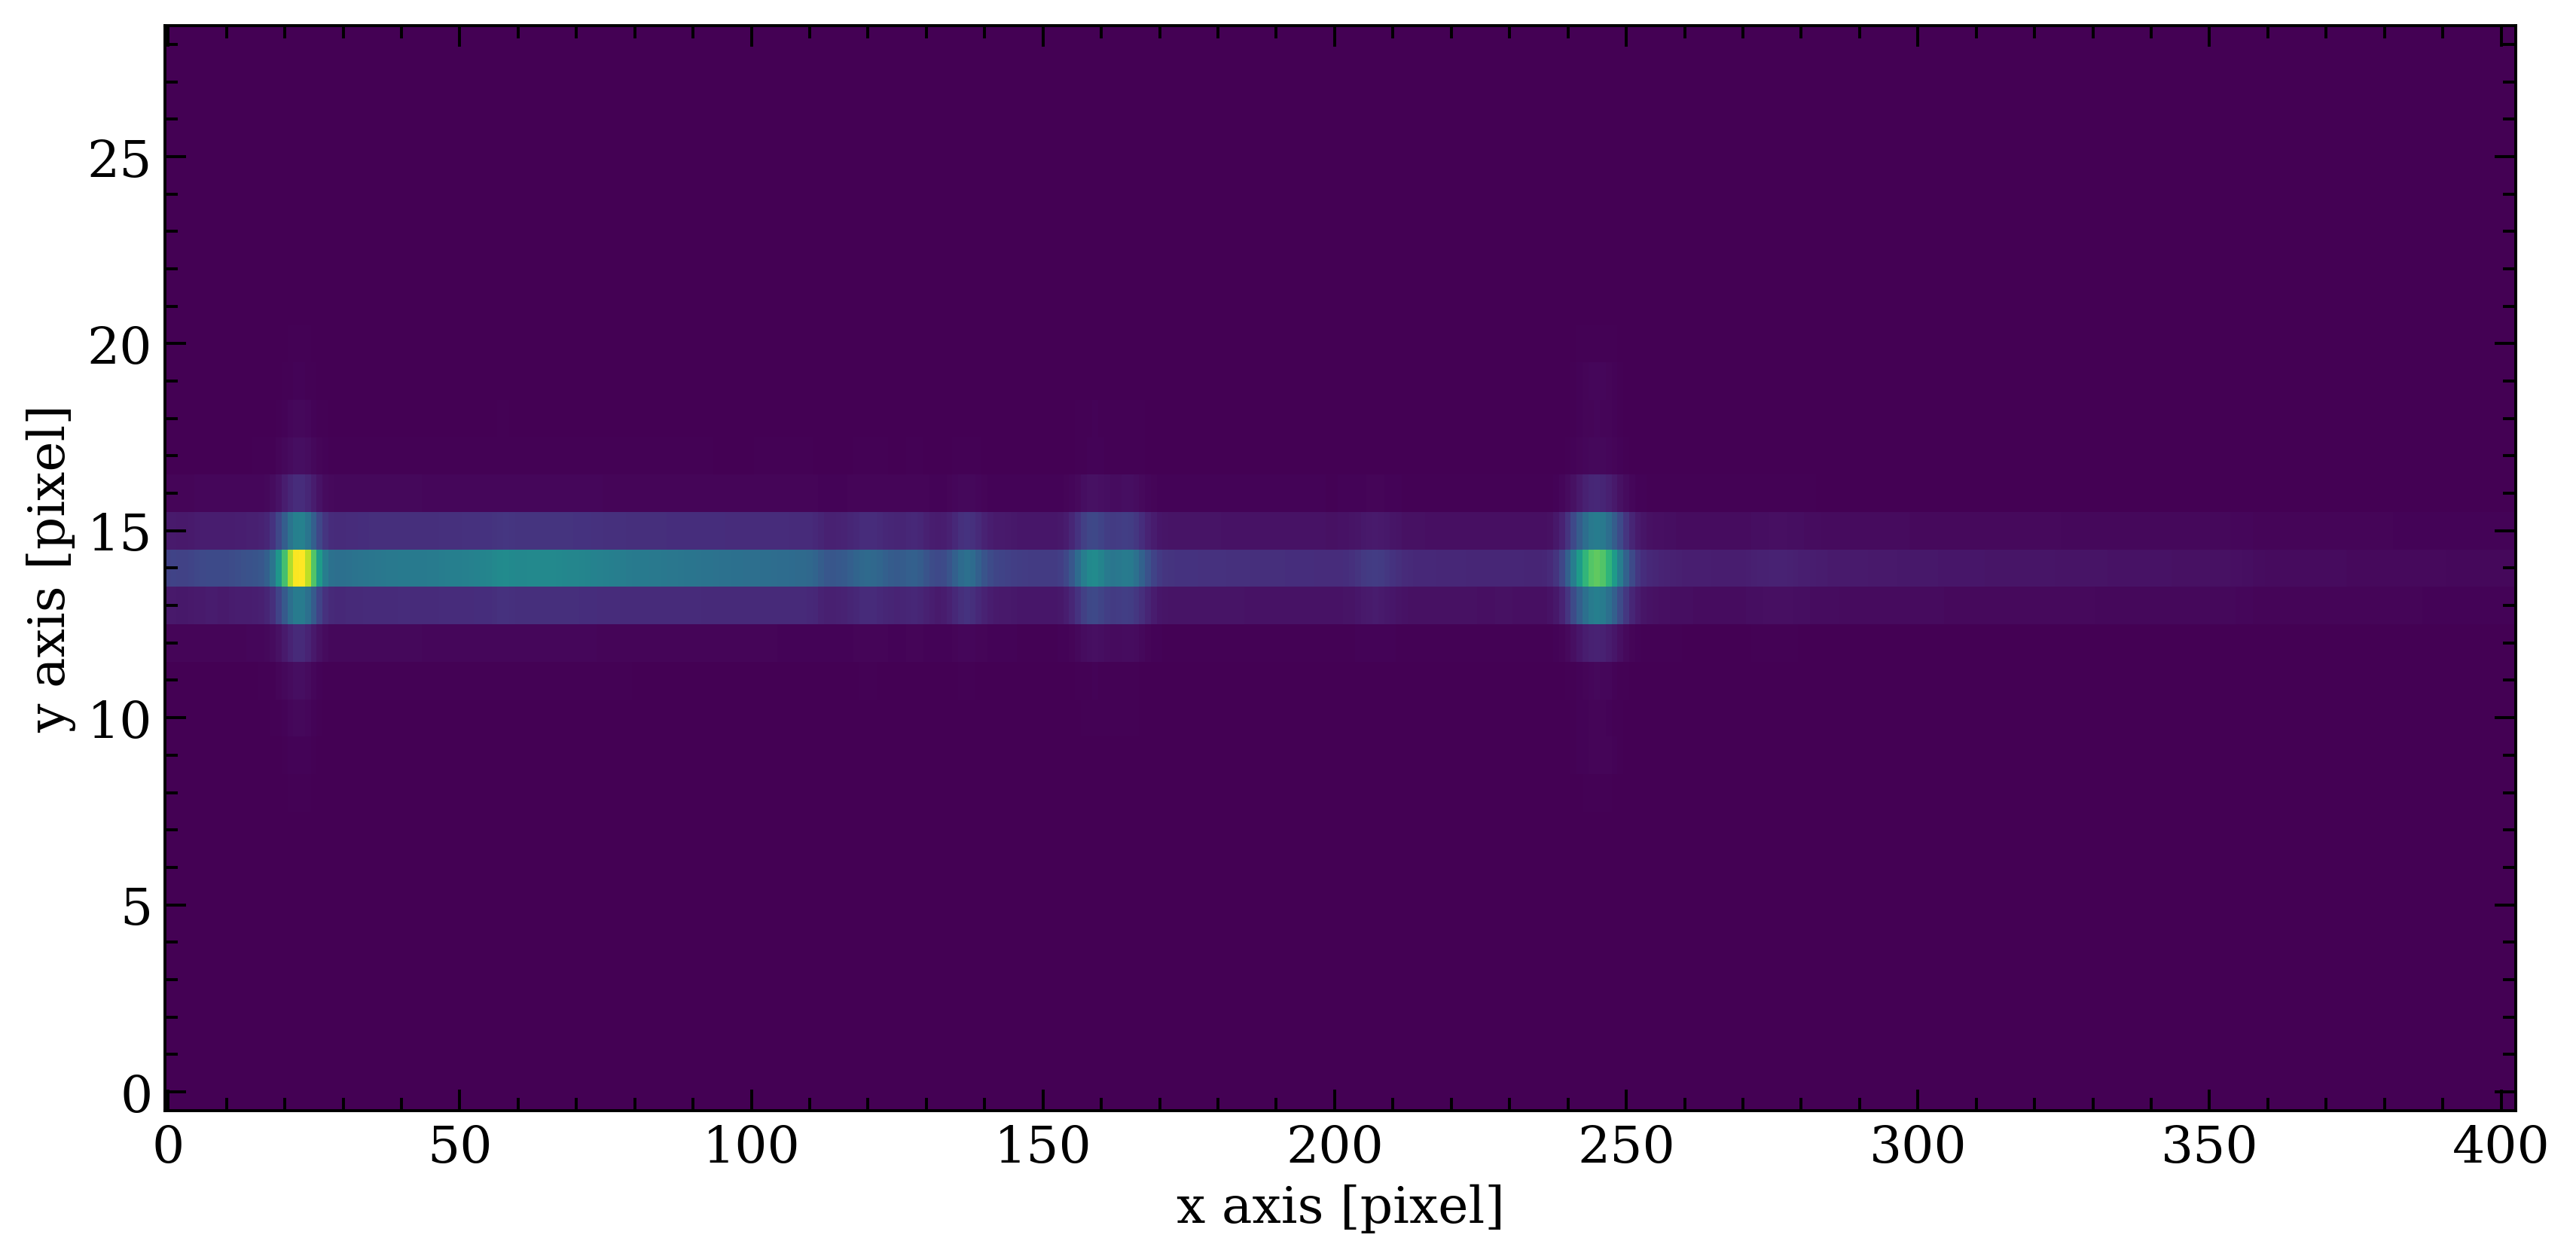

In [18]:
plt.figure(figsize=(10,5))

snr_2d = result['2d']['snr'] # the S/N 2D spectrum

plt.imshow(snr_2d,aspect='auto',origin='lower')

plt.xlabel('x axis [pixel]')
plt.ylabel('y axis [pixel]')

plt.tight_layout()
plt.show()
plt.close('all')

## Ways to expand upon these basics

The sky (Universe?) is the limit!  Below are some examples of what you can do with `pandeia` (most are easy to do in the online ETC as well, but would take MUCH longer to run & download results, etc.).

* run a loop through the various grating/filter pairs
* run a loop that steadily increases the detector science time setup (groups, ints, exps)
* re-run the same calculation but for a range of F444W magnitudes to get depth/sensitivity estimates
* run the same calculation but in IFS mode, so that you can plot S/N spectra pixel-by-pixel
* input your own source spectra on the fly
* define your own backgrounds unique to your source location & date using the JWST Backgrounds Tool [(discussion here)](https://jwst-docs.stsci.edu/jwst-exposure-time-calculator-overview/jwst-etc-pandeia-engine-tutorial/pandeia-backgrounds)
* flip between resolved clumps and extended sources as input scenes (or combine them!)
* run the same defined source through all NIRSpec modes or all MIRI spectroscopic modes

Finally, there are ways to correct the output spectra for the throughput curve of a given grating/filter pair.  An example of how to do that is in the `jwst-sim-corrected.ipynb` notebook.